# load dataset

In [4]:
df=pd.read_csv('AmesHousing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

 #  Fill missing values 

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


After outlier removal: (1642, 81)
RandomForest: best params -> {'model__max_depth': None, 'model__n_estimators': 400}


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


XGBoost: best params -> {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 600}

=== MODEL COMPARISON ===
                        RMSE      R2  RMSE_%_of_mean
LinearRegression  19425.6006  0.9309         10.6378
RandomForest      20831.1297  0.9205         11.4074
XGBoost           18471.7410  0.9375         10.1154

✔ Best model: XGBoost


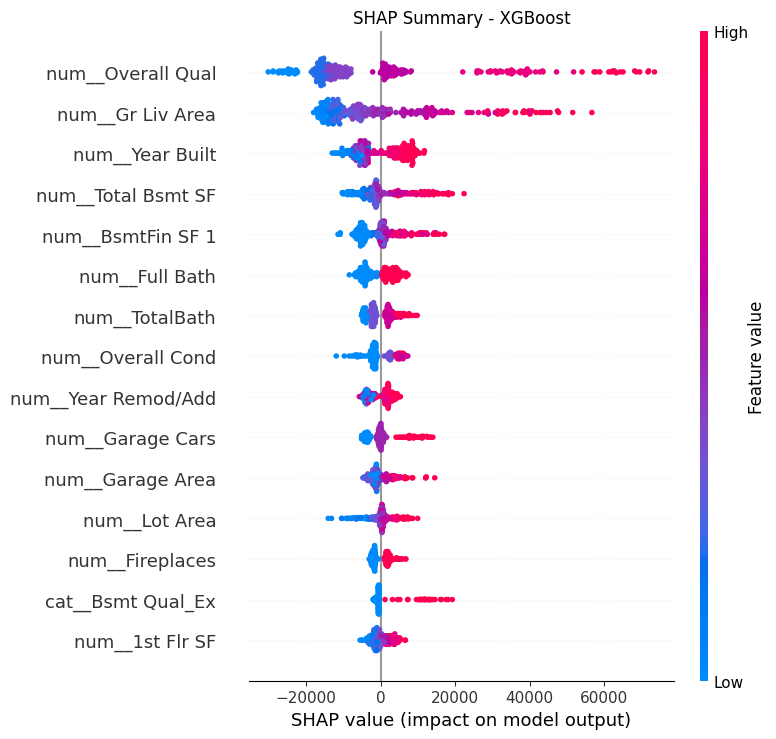

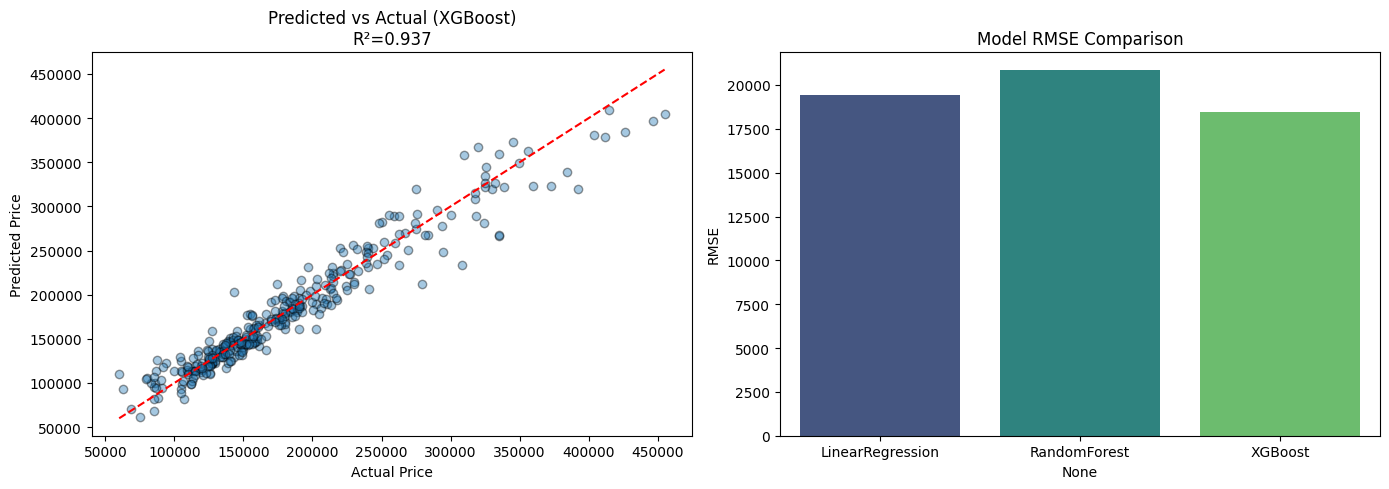


========== FINAL REPORT ==========
LinearRegression    RMSE=  19425.60  R²=0.931  RMSE/mean=10.64%  ❌ FAIL
RandomForest        RMSE=  20831.13  R²=0.920  RMSE/mean=11.41%  ❌ FAIL
XGBoost             RMSE=  18471.74  R²=0.937  RMSE/mean=10.12%  ❌ FAIL


In [4]:
# ============================================================
# HOUSING PRICE PREDICTION - FULL PIPELINE
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("AmesHousing.csv")          # <-- change path
TARGET = "SalePrice"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ------------------------------------------------------------
# 2. REMOVE OUTLIERS  (±3 std on numeric cols)
# ------------------------------------------------------------
num_cols = X.select_dtypes(include=np.number).columns
mask = np.ones(len(X), dtype=bool)
for c in num_cols:
    mu, sd = X[c].mean(), X[c].std()
    mask &= X[c].between(mu - 3*sd, mu + 3*sd)
X, y = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
print(f"After outlier removal: {X.shape}")

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING (interaction terms)
# ------------------------------------------------------------
def engineer(df):
    df = df.copy()
    # Total square footage = basement + 1st + 2nd floor
    if {"TotalBsmtSF","1stFlrSF","2ndFlrSF"}.issubset(df.columns):
        df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + \
                        df["1stFlrSF"].fillna(0) + \
                        df["2ndFlrSF"].fillna(0)
    # Total bathrooms
    bath_cols = [c for c in df.columns if "Bath" in c]
    if bath_cols:
        df["TotalBath"] = df[bath_cols].fillna(0).sum(axis=1)
    # House age
    if {"YearBuilt","YrSold"}.issubset(df.columns):
        df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    return df

X = engineer(X)

# ------------------------------------------------------------
# 4. PREPROCESSING PIPELINE  (impute + encode + scale)
# ------------------------------------------------------------
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # median for numerics
    ("scale",  StandardScaler())
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),  # mode for cats
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# ------------------------------------------------------------
# 5. TRAIN/TEST SPLIT  (80/20)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ------------------------------------------------------------
# 6. MODELS + GRID SEARCH
# ------------------------------------------------------------
models = {
    "LinearRegression": (
        LinearRegression(),
        {}   # no params
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"model__n_estimators":[200,400],
         "model__max_depth":[None,10,20]}
    ),
    "XGBoost": (
        XGBRegressor(random_state=42, objective="reg:squarederror"),
        {"model__n_estimators":[300,600],
         "model__learning_rate":[0.05,0.1],
         "model__max_depth":[4,6]}
    ),
}

results, best_models = {}, {}
for name, (est, grid) in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    if grid:
        gs = GridSearchCV(pipe, grid, cv=3,
                          scoring="neg_root_mean_squared_error",
                          n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_
        print(f"{name}: best params -> {gs.best_params_}")
    else:
        best = pipe.fit(X_train, y_train)

    pred = best.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    pct  = 100 * rmse / y_test.mean()
    results[name] = {"RMSE": rmse, "R2": r2, "RMSE_%_of_mean": pct}
    best_models[name] = best

print("\n=== MODEL COMPARISON ===")
print(pd.DataFrame(results).T.round(4))

# ------------------------------------------------------------
# 7. PICK BEST MODEL
# ------------------------------------------------------------
best_name = min(results, key=lambda k: results[k]["RMSE"])
best_model = best_models[best_name]
y_pred = best_model.predict(X_test)
print(f"\n✔ Best model: {best_name}")

# ------------------------------------------------------------
# 8. FEATURE IMPORTANCE (SHAP)
# ------------------------------------------------------------
X_test_t = best_model.named_steps["prep"].transform(X_test)
feat_names = best_model.named_steps["prep"].get_feature_names_out()

# Use a sample for speed
sample = X_test_t[:300]
explainer = shap.Explainer(best_model.named_steps["model"], sample)
shap_values = explainer(sample)

shap.summary_plot(shap_values, sample, feature_names=feat_names,
                  show=False, max_display=15)
plt.title(f"SHAP Summary - {best_name}")
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=150); plt.show()

# ------------------------------------------------------------
# 9. VISUALIZATIONS
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# (a) Predicted vs Actual
ax[0].scatter(y_test, y_pred, alpha=0.4, edgecolor="k")
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "r--")
ax[0].set_xlabel("Actual Price"); ax[0].set_ylabel("Predicted Price")
ax[0].set_title(f"Predicted vs Actual ({best_name})\nR²={results[best_name]['R2']:.3f}")

# (b) Model comparison RMSE
comp = pd.DataFrame(results).T
sns.barplot(x=comp.index, y=comp["RMSE"], ax=ax[1], palette="viridis")
ax[1].set_title("Model RMSE Comparison")
ax[1].set_ylabel("RMSE")
plt.tight_layout(); plt.savefig("model_eval.png", dpi=150); plt.show()

# ------------------------------------------------------------
# 10. SUMMARY REPORT
# ------------------------------------------------------------
print("\n========== FINAL REPORT ==========")
for m, r in results.items():
    flag = "✅ PASS" if r["RMSE_%_of_mean"] < 10 else "❌ FAIL"
    print(f"{m:18s}  RMSE={r['RMSE']:>10.2f}  "
          f"R²={r['R2']:.3f}  "
          f"RMSE/mean={r['RMSE_%_of_mean']:.2f}%  {flag}")